In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

In [29]:
np.random.seed(42)

# Number of samples
n = 1000


In [30]:
# Generate synthetic features
rainfall = np.random.normal(200, 50, n)              # mm
temperature = np.random.normal(30, 5, n)             # °C
humidity = np.random.normal(70, 10, n)               # %
structure_age = np.random.randint(1, 100, n)         # years
load_index = np.random.uniform(10, 100, n)           # load stress
soil_moisture = np.random.normal(50, 15, n)          # %
extreme_events = np.random.poisson(2, n)             # count per year


In [31]:
# Create failure logic (this is important)
risk_score = (
    0.15 * (rainfall / 300) +
    0.25 * (structure_age / 100) +
    0.20 * (load_index / 100) +
    0.20 * (soil_moisture / 100) +
    0.10 * (humidity / 100) +
    0.10 * (extreme_events / 10)
)

interaction = (rainfall / 300) * (soil_moisture / 100)

risk_score += 0.1 * interaction

In [32]:
failure = (risk_score > 0.6).astype(int)

In [33]:
# Create dataframe
data = pd.DataFrame({
    "rainfall": rainfall,
    "temperature": temperature,
    "humidity": humidity,
    "structure_age": structure_age,
    "load_index": load_index,
    "soil_moisture": soil_moisture,
    "extreme_events": extreme_events,
    "failure": failure
})

In [34]:
# Split data
X = data.drop("failure", axis=1)
y = data["failure"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [36]:
# Train model
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_probs = model.predict_proba(X_test)[:, 1]
threshold = 0.3
y_pred = (y_probs > threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[110  14]
 [  2  74]]
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       124
           1       0.84      0.97      0.90        76

    accuracy                           0.92       200
   macro avg       0.91      0.93      0.92       200
weighted avg       0.93      0.92      0.92       200



In [38]:
# Save model
joblib.dump(model, "infrastructure_model.pkl")

['infrastructure_model.pkl']

In [39]:
print("Model trained and saved successfully.")

Model trained and saved successfully.


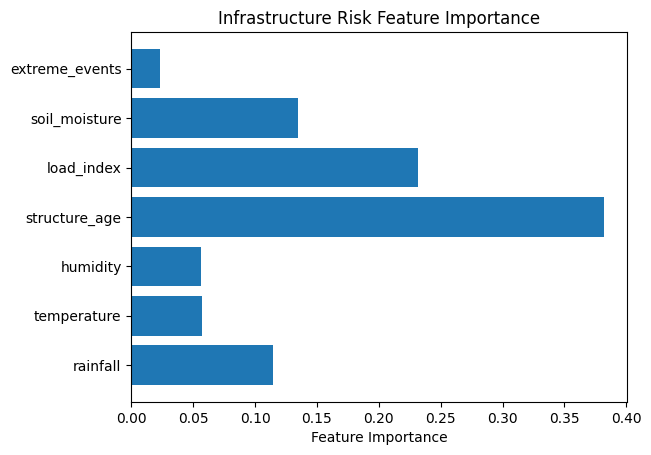

In [40]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Infrastructure Risk Feature Importance")
plt.show()